# What is the temperature between the weather stations?

A weather station measures the air at one point. A reanalysis such as ERA5-Land fills the
map, but in boxes about 9 km across, each holding one number for a city, its fields and the
hillside behind it. Gridded station products such as E-OBS (Cornes et al. 2018) fill the map
by interpolating the stations, and in doing so they stop returning the stations: the value in
a grid box is a smoothed estimate, not the reading taken inside it.

This notebook builds daily maximum temperature (Tmax) on a 1 km grid over the Po Valley for
June to August 2021-2023 with two requirements that pull in different directions:

1. **between stations, the surface obeys physics**: a reduced heat-budget equation in which
   each land-cover class couples the air to the ground at its own rate;
2. **at stations, the surface equals the observation exactly**, every day.

Machine learning has one job: XGBoost learns the heating the equation leaves out, and hands
it back to the equation as a prior. This is physics-informed machine learning in the sense of
Karniadakis et al. (2021), with the constraint imposed as a hard one, as Harder et al. (2023)
do for conservation laws in deep-learning downscaling. The construction itself is older: it
is the variational analysis of Sasaki (1970) and Lorenc (1986), turned around so that the
observations are exact and the dynamics carry the error.

> **Data status.** The elevation model, land cover and station *locations* are real or
> estimated from real sources. The daily fields (ERA5-Land, MODIS, E-OBS, station readings)
> are a **synthetic placeholder** in the shape of the real products, because the services
> could not be reached from the build environment. `download_data.py` fetches the real ones.
> Every number below is therefore a test of the method, not a finding about the Po Valley,
> and every figure made from placeholder data is stamped.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.precision', 3)

from tmax1km import step0, plots, validation
from tmax1km.data import Dataset
from tmax1km.grid import CLASSES, GAMMA
from tmax1km.pde import DaySystem, Params, M2S_TO_KM2H
from tmax1km.anchor import Anchor, Smoother

## The model

Work with temperature reduced to sea level, $\theta = T + \Gamma z$ with $\Gamma = 6.5$ K/km,
so that the 20 K difference between the plain and a 3,000 m summit is taken out before any
modelling. Each day $\theta$ solves a steady balance:

$$\underbrace{\mathbf{u}\cdot\nabla\theta}_{\text{carried by wind}}
\;-\;\underbrace{\kappa\,\nabla^2\theta}_{\text{mixed}}
\;+\;\underbrace{\frac{\theta-\theta_s}{\tau_s(\mathbf{x})}}_{\text{pulled to the surface}}
\;+\;\underbrace{\frac{\theta-\theta_E}{\tau_a}}_{\text{pulled to ERA5-Land}}
\;=\;q(\mathbf{x}),\qquad \theta=\theta_E\ \text{on the boundary.}$$

$\theta_s$ is the MODIS land surface temperature and $\theta_E$ the ERA5-Land Tmax, both
reduced to sea level. $\tau_s$ is the time the air takes to feel the ground beneath it and
$\tau_a$ the time the large-scale atmosphere takes to pull it back. $q$ is whatever heating
the equation leaves out. Land cover enters through the surface coupling. A cell that is 30%
built-up and 70% cropland is coupled through both at once, and rates add:

$$\frac{1}{\tau_s(\mathbf{x})}=\sum_c \frac{f_c(\mathbf{x})}{\tau_c},\qquad c\in\{\text{built-up, cropland, tree cover, grass/shrub, water, other}\}.$$

On the grid (first-order upwind differences for the wind, a five-point Laplacian) this is a
sparse linear system $A\theta = b + q$ with about 113,000 unknowns, factorised once per day.

**Anchoring.** Write $H$ for the matrix that picks out station cells and $y$ for the station
readings. Among all $q$ that make the solution agree with every station, take the one closest
to a prior guess $\hat q$:

$$\min_q\ (q-\hat q)^\top W\,(q-\hat q)\quad\text{subject to}\quad A\theta=b+q,\quad H\theta=y,
\qquad W = I + \ell_q^2 L .$$

$L$ is the grid Laplacian, so $W$ penalises both the size of the correction and its
roughness over a length $\ell_q$. A quadratic objective with linear constraints has a closed
form. With $\theta_0=A^{-1}(b+\hat q)$, the misfit $d=y-H\theta_0$ and $G=HA^{-1}$,

$$q=\hat q+W^{-1}G^\top\left(GW^{-1}G^\top\right)^{-1}d,\qquad \theta=A^{-1}(b+q).$$

Row $i$ of $G$ costs one transposed solve, $A^\top g_i=h_i$. It is station $i$'s
*footprint*: how much a unit of heating in each cell would change that station's reading.

**Fitting.** The physics-only model ($q=0$) has eight parameters: $\kappa$, $\tau_a$ and six
$\tau_c$. Its misfit $J=\tfrac12\lVert H\theta-y\rVert^2$ is minimised with exact gradients
from one extra solve per day rather than one per parameter (the adjoint method):

$$A^\top\lambda = H^\top(H\theta-y),\qquad \frac{\partial J}{\partial p}=\lambda^\top\!\left(\frac{\partial b}{\partial p}-\frac{\partial A}{\partial p}\,\theta\right).$$

## Step 0. The solver against a known answer

Before any data: build a fake truth *from the PDE* with chosen parameters, sample it at 40
station locations over 20 days, and check two things. The anchored solve must return the
station values to within $10^{-6}$ K, and the fit must recover the parameters. The test runs
on the real land-cover map coarsened to 4 km.

Two versions. In the first the truth has $q=0$, so the model is exactly right and recovery
should be exact. In the second the truth contains a smooth $q$ the fit does not know about,
which is the situation on real data.

In [2]:
static = np.load('data/estimated/static_1km.npz')
complete = step0.run(static, n_days=20, q_size=0.0)
missing = step0.run(static, n_days=20, q_size=0.3)

for name, r in (('physics complete (q = 0)', complete), ('physics missing (q unknown)', missing)):
    print(f"{name:30s} anchors missed by {r['anchor_gap']:.1e} K   station RMSE {r['rmse_start']:.3f} -> {r['rmse_fit']:.5f} K")
assert max(complete['anchor_gap'], missing['anchor_gap']) < 1e-6
print(f"planted q recovered where stations can see it: correlation {missing['q_correlation']:.2f}")

rows = ['kappa (m^2/s)', 'tau_a (h)'] + [f'tau {c} (h)' for c in CLASSES]
pd.concat({'physics complete': step0.recovery_table(complete).loc[rows, ['true', 'fitted']],
           'physics missing': step0.recovery_table(missing).loc[rows, ['fitted', 'fitted / true', 'station land-cover share']]}, axis=1).round(2)

physics complete (q = 0)       anchors missed by 2.1e-14 K   station RMSE 0.415 -> 0.00006 K
physics missing (q unknown)    anchors missed by 3.6e-14 K   station RMSE 0.711 -> 0.52803 K
planted q recovered where stations can see it: correlation 0.97


physics complete         physics missing                \
                                true  fitted          fitted fitted / true   
parameter                                                                    
kappa (m^2/s)                  400.0  400.03          135.30          0.34   
tau_a (h)                        5.0    5.00            4.33          0.87   
tau built-up (h)                 1.5    1.50            1.24          0.83   
tau cropland (h)                 4.0    4.00            3.51          0.88   
tau tree cover (h)              10.0   10.00           12.57          1.26   
tau grass/shrub (h)              6.0    5.99            4.99          0.83   
tau water (h)                    3.0    3.00            2.58          0.86   
tau other (h)                    8.0    8.01            7.05          0.88   

                                              
                    station land-cover share  
parameter                                     
kappa (m^2/s)                            NaN  
tau_a (h)                                NaN  
tau built-up (h)                        0.08  
tau cropland (h)                        0.30  
tau tree cover (h)                      0.49  
tau grass/shrub (h)                     0.10  
tau water (h)                           0.01  
tau other (h)                           0.01

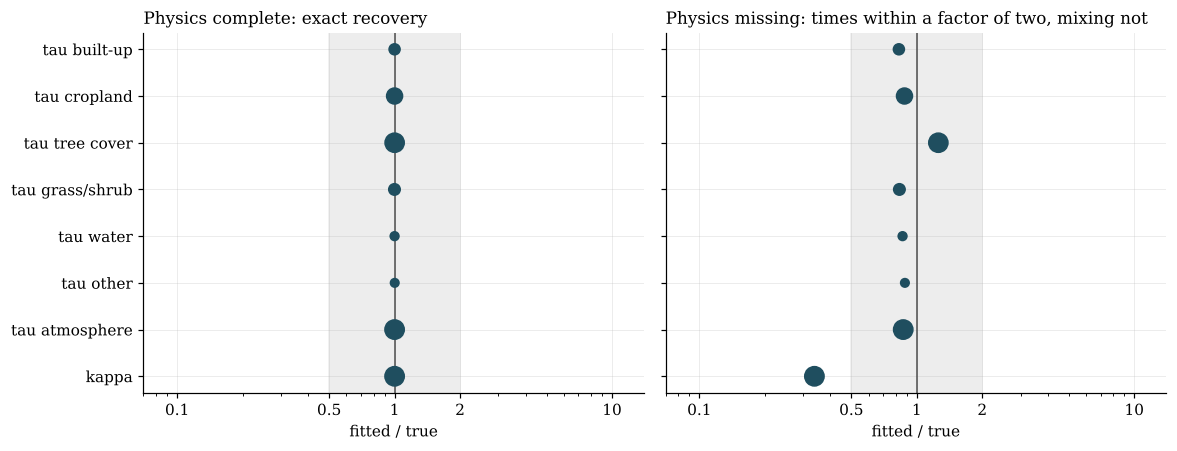

In [3]:
fig = plots.recovery([step0.recovery_table(complete), step0.recovery_table(missing)],
                     ['Physics complete: exact recovery', 'Physics missing: times within a factor of two, mixing not'])
fig.tight_layout()
figstyle.save(fig, 'figures/fig0_step0_recovery')
plt.show()

**The solver passes, and the test says in advance what the fit can be trusted for.** With
complete physics every parameter comes back to three figures. With physics missing, the
relaxation times stay within about 25% of the truth but the mixing coefficient $\kappa$ does
not: the fit uses mixing to mop up what $q$ would have explained. Marker size is the share of
that land cover under the stations; a class no station sits on is fitted from almost nothing.

The reason is visible in the equation. Where transport is weak, the solution is locally

$$\theta\approx\frac{\theta_s/\tau_s+\theta_E/\tau_a}{1/\tau_s+1/\tau_a},$$

a weighted average that depends only on the *ratio* $\tau_s/\tau_a$. The times themselves are
pinned down only through the distances $|\mathbf{u}|\tau$ and $\sqrt{\kappa\tau}$ over which
wind and mixing act.

## Step 1. Data and provenance

Each dataset is taken from the best tier available: real download, then lookup or estimate,
then synthetic.

In [4]:
ds = Dataset()
run = json.load(open('results/run.json'))
stamp = figstyle.watermark if ds.placeholder else (lambda fig: None)
print(f"{ds.grid.nx} x {ds.grid.ny} cells of {ds.grid.dx:.0f} km, {len(ds.stations)} stations, {len(ds.days)} days "
      f"({ds.days[0].date()} to {ds.days[-1].date()}, June-August only)")
ds.provenance.style.hide(axis='index')

460 x 245 cells of 1 km, 39 stations, 276 days (2021-06-01 to 2023-08-31, June-August only)


dataset,tier,source
Elevation (1 km),estimated,"5 arc-minute Mapzen/SRTM grid (pvlib) interpolated, plus synthetic sub-grid roughness"
Land cover fractions,estimated,"Natural Earth coastline, lakes and urban outlines; vegetation zoned by elevation"
Station locations and elevations,real,Meteostat station list (CC BY 4.0)
Station daily Tmax,synthetic,placeholder.py
"ERA5-Land Tmax, skin temperature, wind",synthetic,placeholder.py
MODIS land surface temperature,synthetic,placeholder.py
E-OBS daily tx,synthetic,placeholder.py


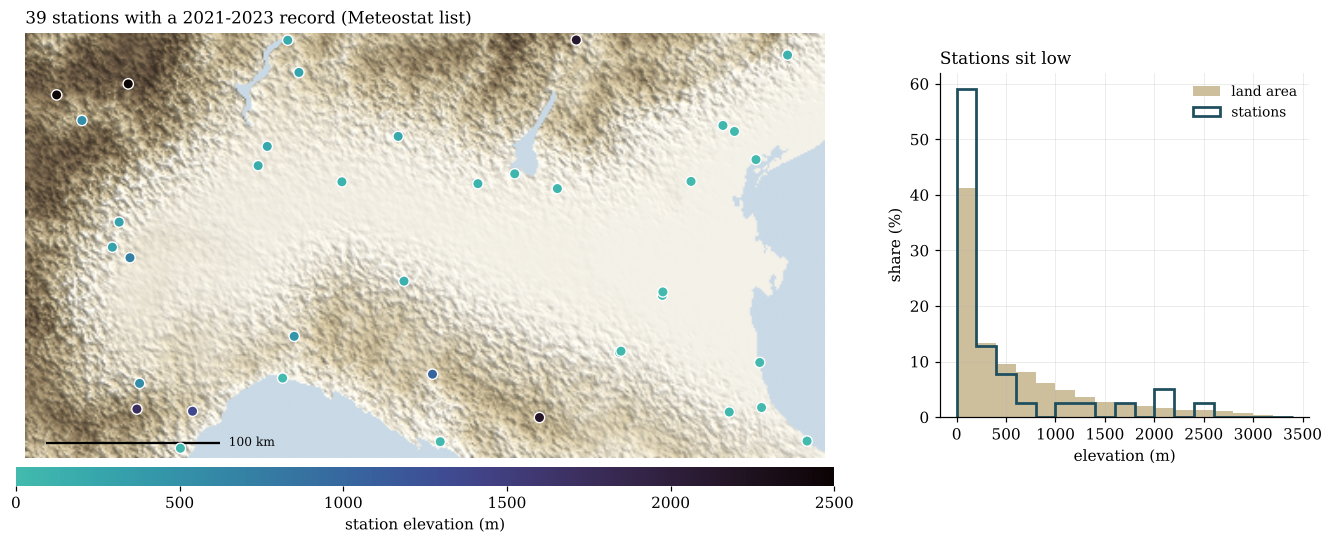

59% of stations are below 200 m; 41% of the land is.


In [5]:
fig = plots.stations(ds)
figstyle.save(fig, 'figures/fig1_stations')
plt.show()
low = (ds.stations.elevation < 200).mean()
print(f"{low:.0%} of stations are below 200 m; {(ds.elev[~ds.sea] < 0.2).mean():.0%} of the land is.")

The station list is real, and it sets the difficulty. Meteostat holds 39 stations here with
an observed record through 2021-2023, mostly airports, about 45 km apart on the plain and
far fewer in the mountains than the terrain would need. The regional agencies (ARPA
Lombardia, Piemonte, Veneto, Emilia-Romagna) run several hundred more; they are the obvious
next source.

## Steps 2-3. One day, solved

The hottest July 2022 day in the station record. Left: the physics-only solution, with each
station drawn as a pin whose head is the reading. Right: the anchored solution. The surface
is sea-level temperature, so terrain is absent by construction and what remains is the
weather and the land cover.

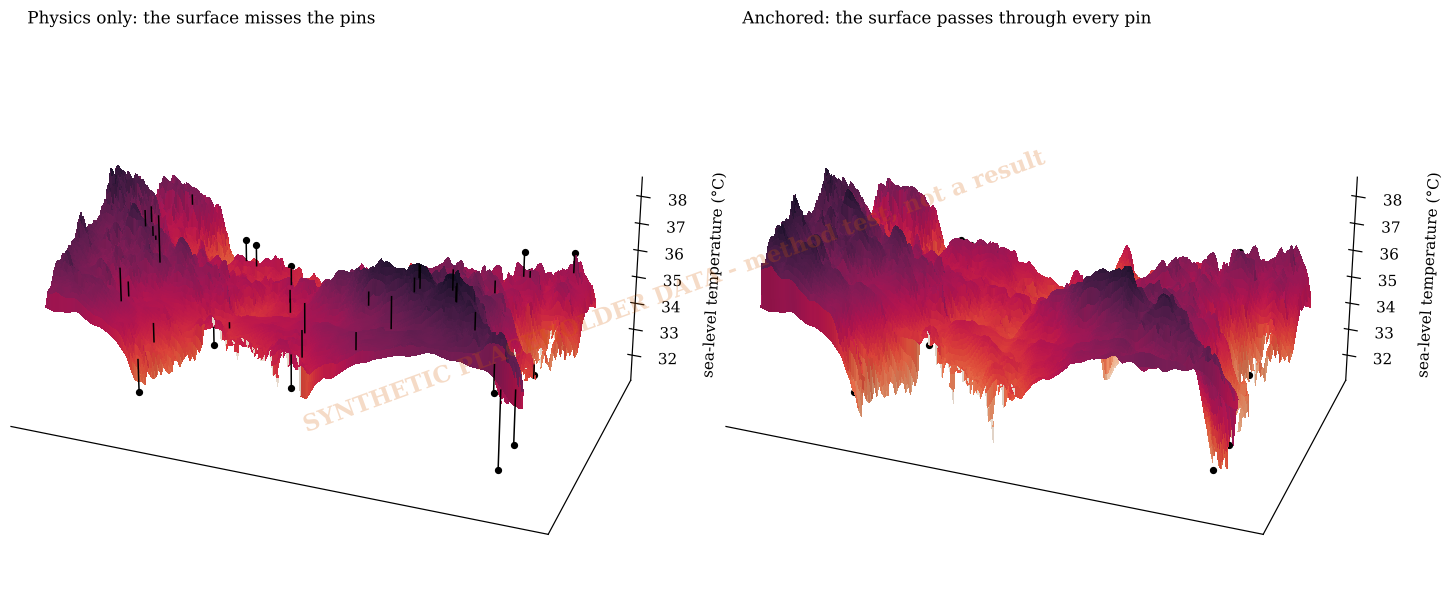

2022-07-23: physics-only misses the stations by 0.94 K (RMSE);
the anchored surface misses them by 4.3e-14 K at worst.
Over all 276 days the worst miss at any anchor is 6.3e-13 K (asserted < 1e-6 in the pipeline).


In [6]:
maps = np.load('results/maps.npz')
hot, windy, still = (int(d) for d in maps['days'])
fig = plots.pde_surfaces(ds, maps)
stamp(fig)
figstyle.save(fig, 'figures/hero', formats=('png',))
plt.show()

ok = np.isfinite(ds.y[hot])
at = lambda f: f[ds.stations.iy[ok], ds.stations.ix[ok]]
gap = pd.read_csv('results/anchor_gap.csv')
print(f"{ds.days[hot].date()}: physics-only misses the stations by {validation.rmse(at(maps['hot_M1']) - ds.y[hot][ok]):.2f} K (RMSE);")
print(f"the anchored surface misses them by {gap.gap[hot]:.1e} K at worst.")
print(f"Over all {len(gap)} days the worst miss at any anchor is {gap.gap.max():.1e} K (asserted < 1e-6 in the pipeline).")

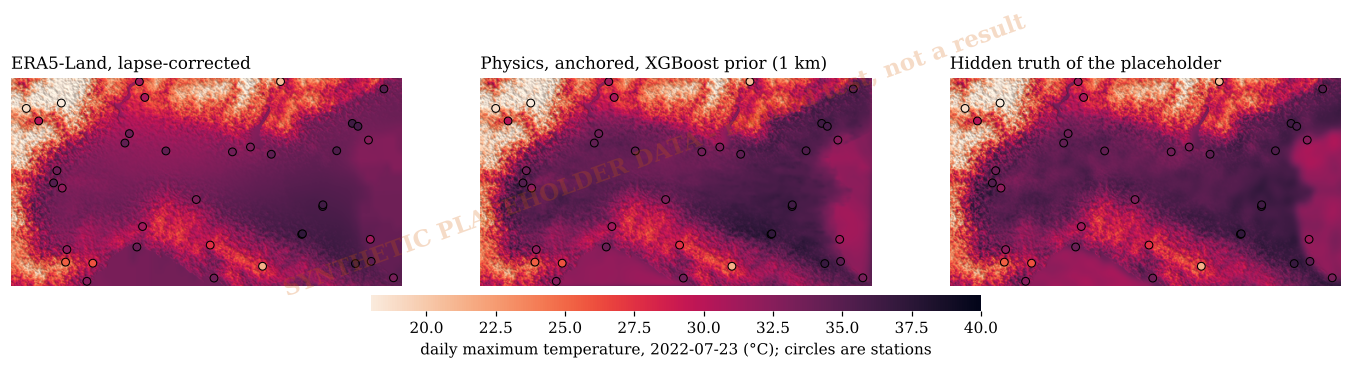

In [7]:
fig = plots.downscaling(ds, maps)
stamp(fig)
figstyle.save(fig, 'figures/fig2_heatwave_day')
plt.show()

## Steps 4-8. Does it work where there are no stations?

Agreement at the anchors is guaranteed, so it proves nothing. The test is at stations the
model never saw. Stations a few kilometres apart read almost the same, so the domain is cut
into 50 km blocks and whole blocks are held out together, five folds in all. Parameters are
fitted on 40 days of 2021-2022; everything is scored on 2023.

| | Model | What it uses |
|---|---|---|
| B0 | ERA5-Land, bilinear, lapse-corrected | no stations |
| B1 | regression on covariates + kriged residuals | stations, statistics |
| B2 | E-OBS | its own station network |
| B3 | XGBoost on station residuals | stations, machine learning |
| M1 | physics only, $q=0$ | stations for eight parameters |
| M2 | physics, anchored, $\hat q=0$ | stations as exact constraints |
| M3 | physics, anchored, $\hat q$ from XGBoost | both |

Within each fold the XGBoost prior is trained only on $q$ fields from solves that exclude
that fold's stations.

In [8]:
pred = validation.add_bands(pd.read_csv('results/predictions_2023.csv', parse_dates=['date']))
models = [m for m in validation.MODELS if m in pred]
overall = validation.skill(pred, models).set_index('model')
by_elev = validation.skill(pred, models, 'elevation band')
by_dist = validation.skill(pred, models, 'anchor distance')

table = pd.DataFrame({'model': [validation.MODELS[m] for m in models], 'RMSE (K)': overall.rmse.values, 'bias (K)': overall.bias.values}, index=models)
for t in (by_elev, by_dist):
    table = table.join(t.pivot(index='model', columns='group', values='rmse').reindex(models)[list(dict.fromkeys(t.group))])
table.to_csv('results/skill_table.csv', float_format='%.3f')
print(f"{len(pred)} held-out station-days, {pred.station.nunique()} stations, 2023")
table.round(2)

3341 held-out station-days, 39 stations, 2023


,model,RMSE (K),bias (K),< 200 m,200-800 m,> 800 m,< 30 km,30-60 km,> 60 km
B0,"ERA5-Land, bilinear + lapse rate",1.34,-0.58,1.39,1.36,1.10,1.29,1.39,1.23
B1,regression + kriged residuals,0.85,0.05,0.81,0.77,1.05,1.13,0.75,0.80
B2,E-OBS,1.49,0.55,1.38,1.08,2.16,1.66,1.40,1.54
B3,XGBoost on station residuals,1.07,0.21,1.03,0.98,1.27,1.29,0.98,1.04
M1,physics only (q = 0),1.03,0.32,1.02,0.88,1.23,1.19,0.96,1.03
M2,"physics, anchored",0.83,0.04,0.77,0.73,1.09,0.95,0.77,0.84
M3,"physics, anchored, XGBoost prior for q",0.79,0.03,0.69,0.72,1.10,0.86,0.74,0.81


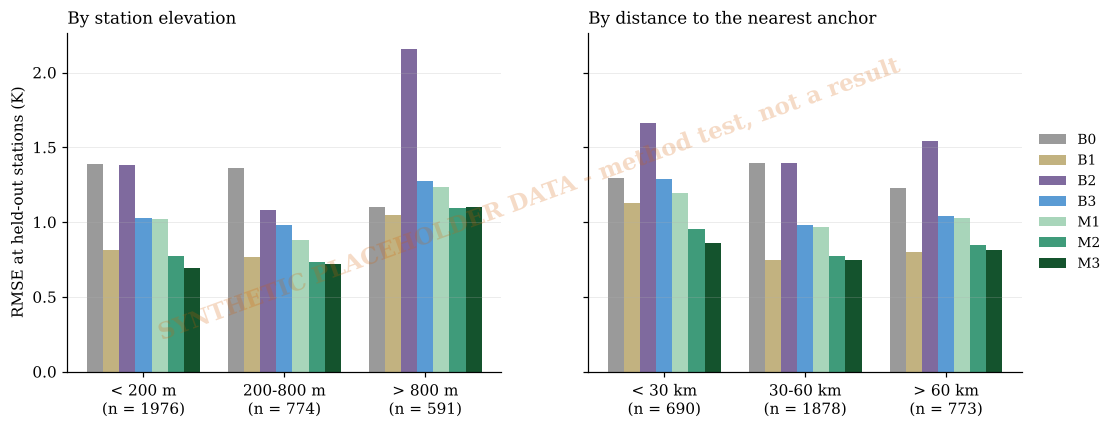

RMSE difference with a 95% interval from resampling stations (negative: first model better)
  M1 - B0: -0.305 K  [-0.440, -0.179]
  M2 - M1: -0.202 K  [-0.262, -0.148]
  M3 - M2: -0.043 K  [-0.079, -0.015]
  M3 - B3: -0.280 K  [-0.345, -0.218]
  M3 - B1: -0.064 K  [-0.139, +0.002]


In [9]:
fig = plots.skill_bars(by_elev, by_dist, models)
stamp(fig)
figstyle.save(fig, 'figures/fig3_skill')
plt.show()

print("RMSE difference with a 95% interval from resampling stations (negative: first model better)")
for a, b in [('M1', 'B0'), ('M2', 'M1'), ('M3', 'M2'), ('M3', 'B3'), ('M3', 'B1')]:
    d, (lo, hi) = validation.paired_bootstrap(pred, a, b)
    print(f"  {a} - {b}: {d:+.3f} K  [{lo:+.3f}, {hi:+.3f}]")

**Anchored physics matches the standard geostatistical method; it does not clearly beat it.**
Physics alone (M1), with eight fitted numbers and no station reading on the day, removes a
quarter of ERA5-Land's error (1.34 to 1.03 K). Using the stations as exact constraints takes
it to 0.83 K, and the XGBoost prior to 0.79 K. Regression with kriged residuals (B1) reaches
0.85 K. The 0.06 K gap between M3 and B1 has a 95% interval of -0.14 to +0.00 K: on 39
stations it cannot be called a difference. What can be said is that M3 beats XGBoost applied
directly to the same covariates (B3) by 0.28 K, and that the prior for $q$ is a real, if
small, improvement over no prior (0.04 K, interval excluding zero).

Two splits qualify this. Above 800 m no model improves on lapse-corrected ERA5-Land (about
1.1 K for all of them). The model assumes 6.5 K/km while the placeholder's lapse rate changes
from day to day, an error the surface coupling cannot repair. And error does not grow with
distance from the nearest anchor: the "< 30 km" group is the worst because it is mostly
paired mountain and coastal stations, so that split measures terrain more than distance.

B2 is a stand-in. The placeholder E-OBS is interpolated from its own invented 30-station
network, so its score reflects that choice and says nothing about the real product.

In [10]:
if ds.placeholder:
    truth = pd.read_csv('results/truth_check.csv')
    check = np.sqrt(truth.groupby('scope')[[m for m in ['B0', 'B2', 'M1', 'M2', 'M3'] if m in truth]].mean())
    display(check.round(3))

,B0,B2,M1,M2,M3
scope,,,,,
all land cells,1.217,1.146,0.854,0.631,0.632
land cells far from stations,1.199,1.198,0.860,0.654,0.658


The placeholder has a hidden truth, so the product can also be checked at every land cell
rather than only at stations (all stations as anchors, all 276 days). The ranking holds:
1.22 K for ERA5-Land, 0.85 K for physics only, 0.63 K anchored. The XGBoost prior adds
nothing at map level (0.63 K with or without it), although it helped at held-out stations.
Its gain there came mostly from coastal stations; averaged over the domain it is not
visible. On real data this check does not exist, which is the reason to run it here.

## Step 9. What the fit says about the physics

In [11]:
tau = pd.read_csv('results/tau_by_land_cover.csv').set_index('land_cover')
params = pd.read_csv('results/m1_params.csv').set_index('model')
p = Params.unpack(params.loc['all', Params.names()].values.astype(float))
print(f"kappa = {p.kappa / M2S_TO_KM2H:.0f} m^2/s (search bounds 10 to 10,000)    tau_a = {p.tau_a:.2f} h    smoothness length l_q = {run['l_q_km']:.0f} km")
tau.rename(columns=dict(tau_h='tau (h)', tau_fold_min='lowest fold', tau_fold_max='highest fold', ratio_to_tau_a='tau / tau_a',
                        footprint_share='share of station footprints', area_share='share of area')).round(2)

kappa = 25 m^2/s (search bounds 10 to 10,000)    tau_a = 0.78 h    smoothness length l_q = 250 km


,tau (h),lowest fold,highest fold,tau / tau_a,share of station footprints,share of area
land_cover,,,,,,
built-up,2.37,2.12,2.66,3.02,0.20,0.09
cropland,3.56,3.09,3.87,4.54,0.31,0.31
tree cover,4.19,2.74,5.43,5.35,0.31,0.38
grass/shrub,48.00,46.64,48.00,61.23,0.08,0.11
water,48.00,48.00,48.00,61.23,0.08,0.09
other,3.58,2.76,25.10,4.57,0.02,0.02


In [12]:
lq = pd.read_csv('results/lq_search.csv').groupby('l_q').error.apply(validation.rmse).rename('held-out RMSE (K), 2021-2022')
display(lq.round(3).to_frame().T)
scales = pd.read_csv('results/length_scales.csv').set_index('day')
scales.rename(columns=dict(wind_kmh='wind (km/h)', tau_h='tau (h)', advective_km='|u| tau (km)', diffusive_km='sqrt(kappa tau) (km)',
                           numerical_diffusion_m2s='numerical diffusion (m^2/s)')).round(2)

l_q,10.0,25.0,60.0,120.0,250.0
"held-out RMSE (K), 2021-2022",0.938,0.895,0.822,0.8,0.799


,wind (km/h),tau (h),|u| tau (km),sqrt(kappa tau) (km),numerical diffusion (m^2/s)
day,,,,,
median day,7.48,0.65,4.90,0.24,1038.59
calmest day,2.17,0.65,1.42,0.24,301.55
windiest day,32.77,0.65,21.46,0.24,4551.24


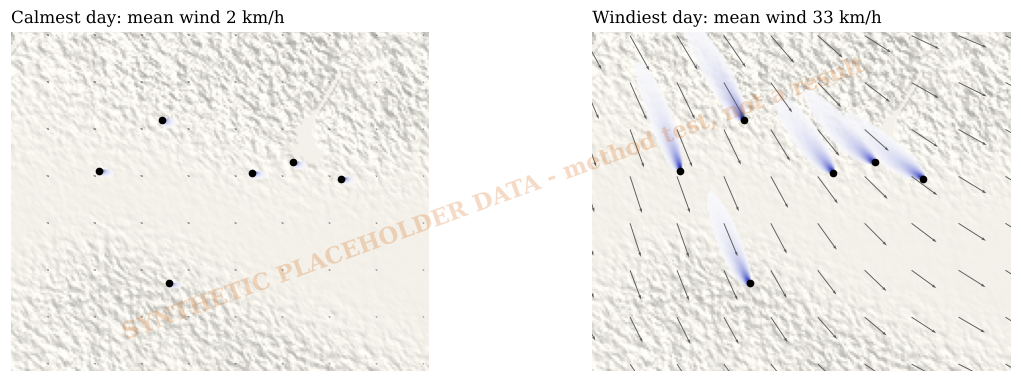

,n,M1 with wind,M1 wind off,M2 with wind,M2 wind off
days,,,,,
all days,3341,1.019,1.052,0.814,0.859
wind below 15 km/h,2714,1.027,1.063,0.817,0.869
wind above 15 km/h,627,0.981,1.003,0.801,0.811


M2 with wind minus M2 with the wind term removed and refitted: -0.045 K  [-0.091, +0.001]


In [13]:
fig = plots.footprints(ds, maps)
stamp(fig)
figstyle.save(fig, 'figures/fig4_footprints')
plt.show()

wind = pred.wind_kmh > 15
rows = []
for label, g in (('all days', pred), ('wind below 15 km/h', pred[~wind]), ('wind above 15 km/h', pred[wind])):
    s = validation.skill(g, ['M1_wind', 'M1_calm', 'M2_wind', 'M2_calm']).set_index('model').rmse
    rows.append(dict(days=label, n=len(g), **{'M1 with wind': s['M1_wind'], 'M1 wind off': s['M1_calm'], 'M2 with wind': s['M2_wind'], 'M2 wind off': s['M2_calm']}))
display(pd.DataFrame(rows).set_index('days').round(3))
d, (lo, hi) = validation.paired_bootstrap(pred, 'M2_wind', 'M2_calm')
print(f"M2 with wind minus M2 with the wind term removed and refitted: {d:+.3f} K  [{lo:+.3f}, {hi:+.3f}]")

**The fitted times are short, and the transport is weaker than the grid.** Three land-cover
classes are identified, in the same order in every fold: built-up land couples to the surface
fastest (2.4 h), then cropland (3.6 h), then tree cover (4.2 h). Grass/shrub and water sit on
the upper bound of the search (48 h). The fit prefers to disconnect them, so those two
numbers are bounds, not estimates. "Other" ranges from 2.8 to 25 h between folds; it holds 2%
of the station footprints and should be read as unknown. As Step 0 warned, the ratios to
$\tau_a$ are the part to trust.

The pull to ERA5-Land is strong ($\tau_a \approx 0.8$ h), so a cell forgets what is upwind
within about 40 minutes. On a median day that is 5 km of wind transport, and 21 km on the
windiest day. Mixing is smaller still: the fitted $\kappa$ is 25 m²/s, near the bottom of the
allowed range, which gives 0.24 km. That number should not be read as physical. First-order
upwind differencing adds numerical diffusion of $|u|\Delta x/2$, about 1,000 m²/s at 1 km
and median wind, forty times the fitted $\kappa$. The explicit mixing term has nothing left
to do.

Two consequences follow.

**The wind term matters a little.** Removing it and refitting costs M2 0.045 K, with an
interval that just reaches zero (-0.09 to +0.00 K). The cost is smaller on windy days
(0.01 K) than on calm ones (0.05 K), which is not what transport would produce, so part of it
is the refitted parameters rather than the wind. In a basin this calm it is a second-order
term.

**The physics is local.** A station's footprint is a plume a few kilometres long (figure
above). What carries a station's information across the 45 km to its neighbours is the
smoothness operator $W$. Held-out error falls as $\ell_q$ grows and flattens beyond about
120 km (0.80 K at both 120 and 250 km), which means the stations are mainly correcting
ERA5-Land's broad errors. The division of labour is statistics for reach and physics for
local shape.

## Where the equation is missing heat

Averaged over all days, $q$ is the heating the equation needed and did not have. If the
physics were complete it would be noise. Beside it, the land cover.

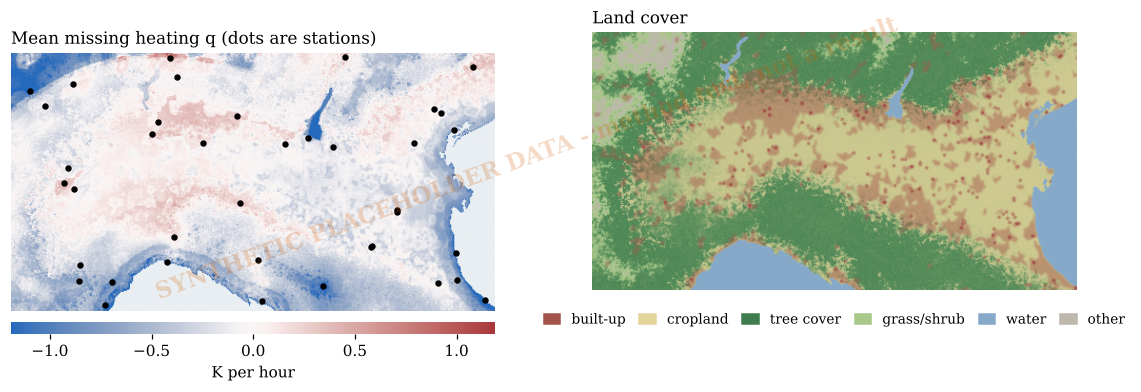

XGBoost's features for q, by importance: water 0.51, coast 0.07, day_of_year 0.06, wind 0.05, other 0.04


,built-up,cropland,tree cover,grass/shrub,water,other
mean q where this class dominates (K/h),0.033,-0.103,-0.241,-0.345,-0.837,-0.383


In [14]:
fig = plots.missing_physics(ds, maps)
stamp(fig)
figstyle.save(fig, 'figures/fig5_missing_physics')
plt.show()

report = pd.read_csv('results/xgb_q_report.csv').set_index('model')
importance = report.loc['all', [c for c in report.columns if c not in ('rows', 'q_sd', 'train_r2')]].astype(float).sort_values(ascending=False)
print("XGBoost's features for q, by importance:", ", ".join(f"{k} {v:.2f}" for k, v in importance.head(5).items()))
land = ~ds.sea
dominant = ds.frac.argmax(0)
pd.Series({c: maps['mean_q_m3'][land & (dominant == i)].mean() for i, c in enumerate(CLASSES)}, name='mean q where this class dominates (K/h)').round(3).to_frame().T

**$q$ recovers the ordering that was planted.** In the placeholder each land-cover class
warms or cools the afternoon air by a known amount (built-up +2.6 K, cropland +0.6,
grass/shrub -0.4, other -0.5, tree cover -1.2, water -3.2). Mean $q$ is highest where
built-up land dominates (+0.03 K/h), then cropland (-0.10), tree cover (-0.24), grass/shrub
(-0.35), other (-0.38), and lowest over water (-0.84). The ends are right and the middle is
shuffled: grass/shrub and "other" lie in the mountains, where the fixed lapse rate adds a
cold bias that $q$ also has to absorb. Coasts and lakes stand out because the equation has
no sea breeze, and the water fraction is the feature XGBoost uses most. The mostly negative
values say the equation runs warm overall (M1's bias is +0.3 K).

## The product

The same day as above, as it would be delivered: Tmax at 1 km on the terrain. Interactive
versions of this map and of the $q$ map are in `maps/` (built by `make_maps.py`).

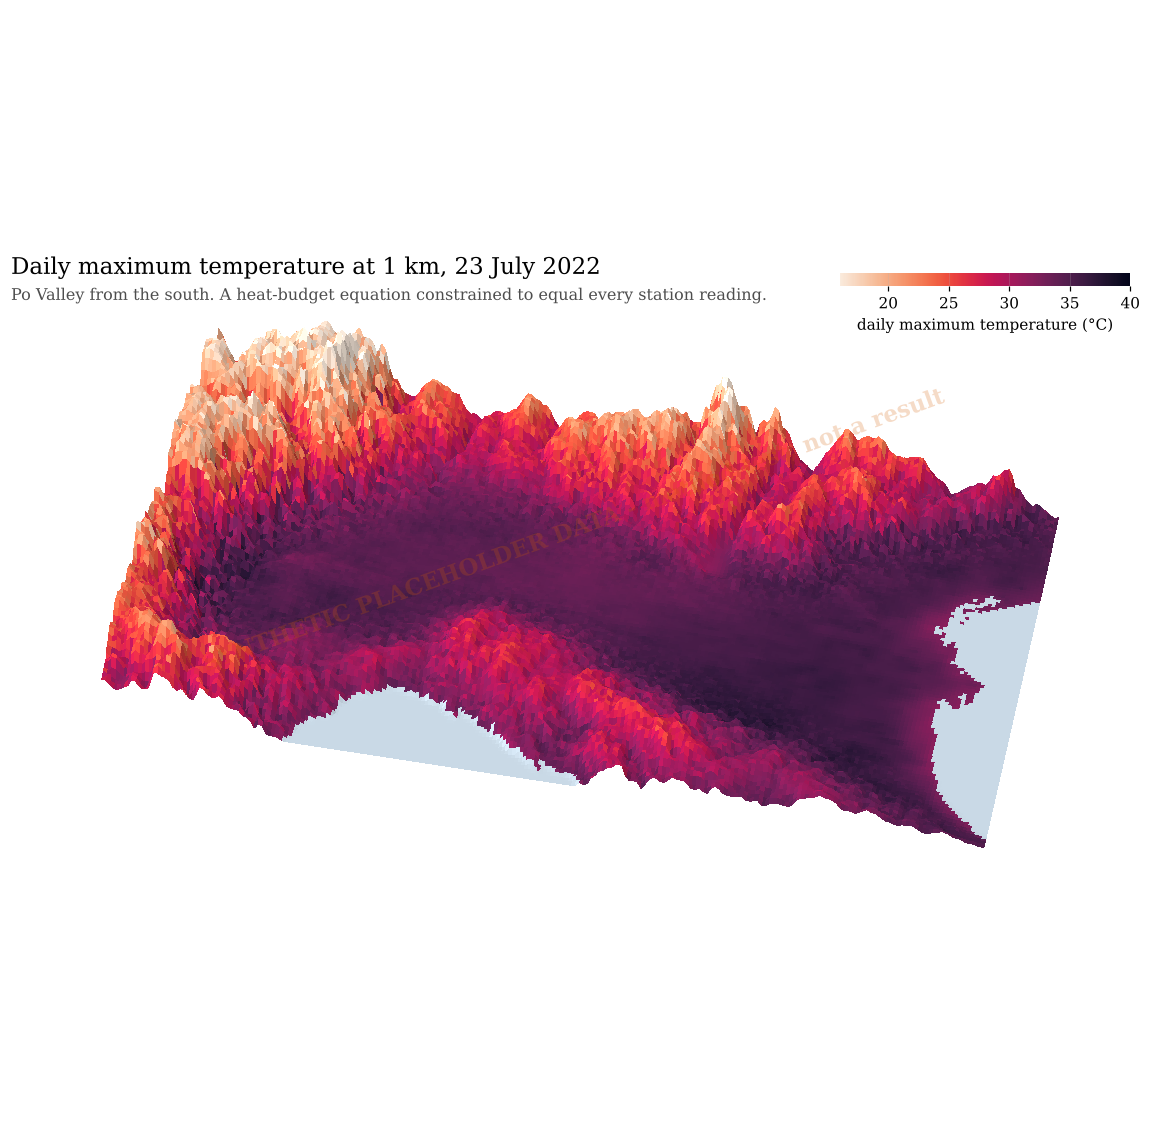

In [15]:
fig = plots.cover(ds, maps, width=11, height=5.5)
stamp(fig)
plt.show()

## Limits

- **Placeholder daily fields.** Every skill number above is a test of the method on synthetic
  data built to be harder than the model (different transport, a lapse rate that varies).
  None is a statement about the Po Valley.
- **Steady state.** One balance per day stands in for an afternoon. There is no morning, no
  heat storage and no memory of the previous day.
- **Single layer.** No boundary-layer depth, no inversion, no sea-breeze circulation. Valley
  cold pools and breezes can only appear through $q$.
- **Clear-sky LST.** MODIS sees the surface only without cloud. Elsewhere $\theta_s$ is
  ERA5-Land skin temperature plus a monthly offset, weakest on the days that differ most from
  the monthly mean. Over open sea neither product exists and the nearest land values are used.
- **Fixed lapse rate.** 6.5 K/km every day. Above 800 m this is the largest error left.
- **Numerical diffusion** exceeds the fitted $\kappa$, so $\kappa$ cannot be interpreted. A
  second-order or flux-limited scheme is needed before it can.
- **39 stations.** Enough to rank the models, not enough to separate M3 from
  regression-kriging.

## Credits

- **ERA5-Land.** Muñoz-Sabater, J. et al. (2021). ERA5-Land: a state-of-the-art global reanalysis dataset for land applications. *Earth System Science Data* 13, 4349-4383. [doi:10.5194/essd-13-4349-2021](https://doi.org/10.5194/essd-13-4349-2021)
- **E-OBS.** Cornes, R. C., van der Schrier, G., van den Besselaar, E. J. M. & Jones, P. D. (2018). An ensemble version of the E-OBS temperature and precipitation data sets. *JGR Atmospheres* 123, 9391-9409. [doi:10.1029/2017JD028200](https://doi.org/10.1029/2017JD028200)
- **Variational analysis.** Sasaki, Y. (1970). Some basic formalisms in numerical variational analysis. *Monthly Weather Review* 98, 875-883. Lorenc, A. C. (1986). Analysis methods for numerical weather prediction. *Quarterly Journal of the Royal Meteorological Society* 112, 1177-1194. [doi:10.1002/qj.49711247414](https://doi.org/10.1002/qj.49711247414)
- **The closest published relative.** Wilson, B., Porter, J. R., Kearns, E. J., Hoffman, J. S., Shu, E., Lai, K., Bauer, M. & Pope, M. (2022). High-resolution estimation of monthly air temperature from joint modeling of in situ measurements and gridded temperature data. *Climate* 10(3), 47. [doi:10.3390/cli10030047](https://doi.org/10.3390/cli10030047) (First Street Foundation; stations, gridded temperature and Landsat LST joined geostatistically.)
- **Physics-informed machine learning.** Karniadakis, G. E. et al. (2021). Physics-informed machine learning. *Nature Reviews Physics* 3, 422-440. Harder, P. et al. (2023). Hard-constrained deep learning for climate downscaling. *Journal of Machine Learning Research* 24(365), 1-40.
- **Land cover.** Zanaga, D. et al. (2022). ESA WorldCover 10 m 2021 v200. [doi:10.5281/zenodo.7254221](https://doi.org/10.5281/zenodo.7254221)
- **XGBoost.** Chen, T. & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *KDD '16*, 785-794. [doi:10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)
- **Used in this run.** Station list: Meteostat (CC BY 4.0). Coastline, lakes and urban outlines: Natural Earth. Coarse elevation: Mapzen terrain tiles (SRTM, GMTED2010, ETOPO1) as bundled with pvlib.